# Analisis Time Series, Ekstraksi Fitur, PCA, dan K-Means Clustering

**Proyek Sains Data (PSD)**  
**Polutan:** CO, NO₂, SO₂  
**Wilayah salah satu anggota:** Kecamatan Menganti, Kabupaten Gresik  
**Dataset kelas:** hasil ekstraksi TSFEL dari seluruh mahasiswa


## Catatan ruang lingkup

Instruksi kerja yang sedang digunakan menyatakan bahwa ekstraksi dilakukan untuk **3 polutan sekaligus**:

- CO → 68 fitur
- NO₂ → 68 fitur
- SO₂ → 68 fitur

Total dataset utama untuk clustering:

**68 × 3 = 204 fitur per mahasiswa.**

In [226]:
# 1. Import library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")


# 2. Dataset

## Dataset Kelas

Dataset berikut merupakan hasil ekstraksi fitur TSFEL dari seluruh anggota kelas. Setiap polutan memiliki 68 fitur.

- [Download Dataset NO₂](../data/class/ekstraksi_fitur_no2.csv)
- [Download Dataset CO](../data/class/ekstraksi_fitur_co.csv)
- [Download Dataset SO₂](../data/class/ekstraksi_fitur_so2.csv)

## Data Time Series Kecamatan Menganti

Data berikut merupakan data time series hasil crawling Sentinel-5P untuk Kecamatan Menganti, Kabupaten Gresik.

- [Download Data Time Series NO₂](../data/processed/menganti_NO2_daily.csv)
- [Download Data Time Series CO](../data/processed/menganti_CO_daily.csv)
- [Download Data Time Series SO₂](../data/processed/menganti_SO2_daily.csv)

## Data Hasil Preprocessing

Data berikut merupakan hasil preprocessing sebelum dilakukan ekstraksi fitur TSFEL.

- [Download Preprocessed NO₂](../data/processed/menganti_NO2_preprocessed.csv)
- [Download Preprocessed CO](../data/processed/menganti_CO_preprocessed.csv)
- [Download Preprocessed SO₂](../data/processed/menganti_SO2_preprocessed.csv)

In [227]:
# 3. Konfigurasi path

BASE = Path("..")

CLASS_DIR = BASE / "data" / "class"
PROCESSED_DIR = BASE / "data" / "processed"
FEATURE_DIR = BASE / "data" / "features"

NO2_CLASS = CLASS_DIR / "ekstraksi_fitur_no2.csv"
CO_CLASS = CLASS_DIR / "ekstraksi_fitur_co.csv"
SO2_CLASS = CLASS_DIR / "ekstraksi_fitur_so2.csv"

NO2_TS = PROCESSED_DIR / "menganti_NO2_preprocessed.csv"
CO_TS = PROCESSED_DIR / "menganti_CO_preprocessed.csv"
SO2_TS = PROCESSED_DIR / "menganti_SO2_preprocessed.csv"

print("CLASS_DIR   :", CLASS_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FEATURE_DIR :", FEATURE_DIR)


CLASS_DIR   : ..\data\class
PROCESSED_DIR: ..\data\processed
FEATURE_DIR : ..\data\features


# 4. EDA — Time Series CO, NO₂, dan SO₂

Setiap polutan dibuat sebagai time series. Data yang digunakan untuk visualisasi berasal dari hasil preprocessing sehingga tidak memiliki missing value.


In [228]:
# 4.1 Membaca time series

ts_no2 = pd.read_csv(NO2_TS, parse_dates=["date"])
ts_co = pd.read_csv(CO_TS, parse_dates=["date"])
ts_so2 = pd.read_csv(SO2_TS, parse_dates=["date"])

print("NO2:", ts_no2.shape, "missing =", ts_no2["NO2"].isna().sum())
print("CO :", ts_co.shape, "missing =", ts_co["CO"].isna().sum())
print("SO2:", ts_so2.shape, "missing =", ts_so2["SO2"].isna().sum())


NO2: (366, 2) missing = 0
CO : (366, 2) missing = 0
SO2: (366, 2) missing = 0


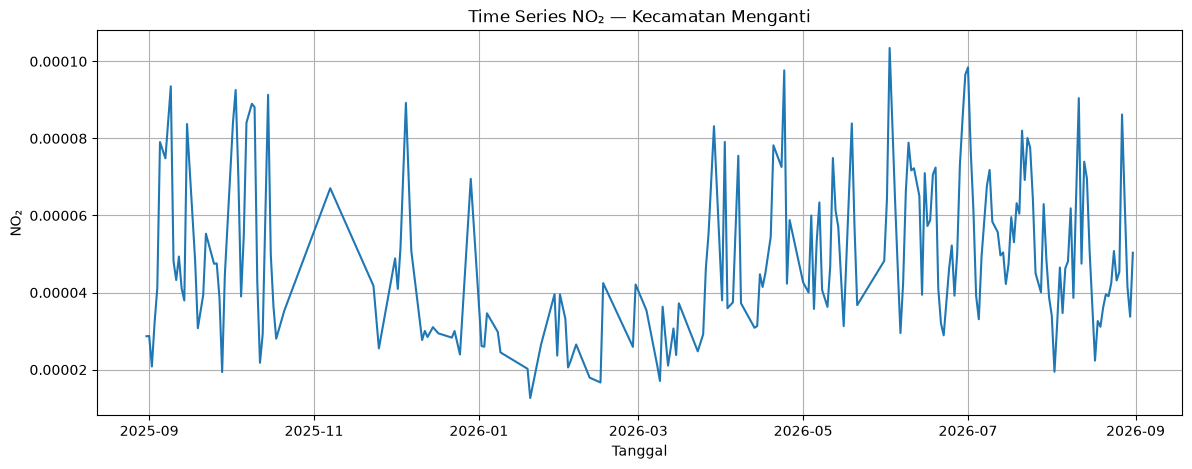

In [229]:
# 4.2 Plot time series NO2

plt.figure(figsize=(14, 5))
plt.plot(ts_no2["date"], ts_no2["NO2"])
plt.title("Time Series NO₂ — Kecamatan Menganti")
plt.xlabel("Tanggal")
plt.ylabel("NO₂")
plt.grid(True)
plt.show()


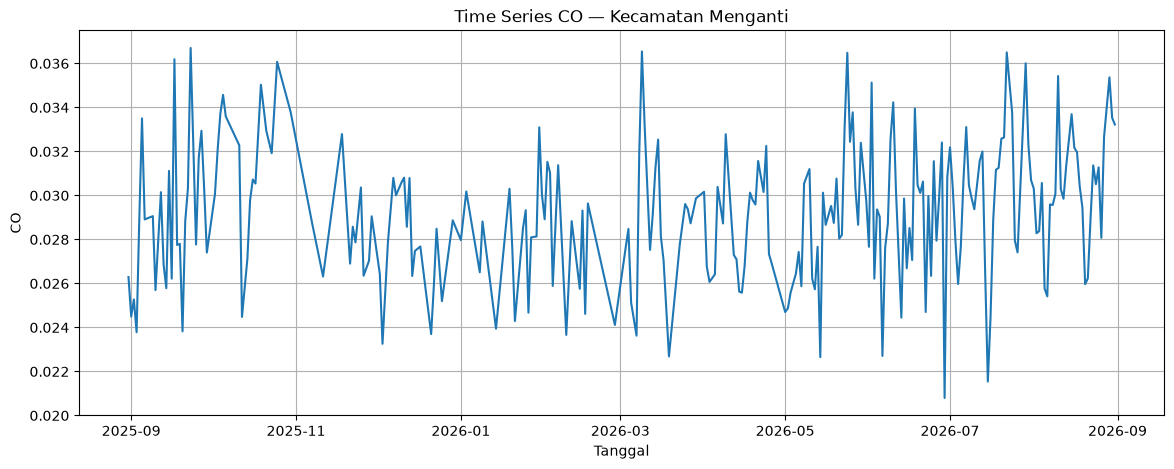

In [230]:
# 4.3 Plot time series CO

plt.figure(figsize=(14, 5))
plt.plot(ts_co["date"], ts_co["CO"])
plt.title("Time Series CO — Kecamatan Menganti")
plt.xlabel("Tanggal")
plt.ylabel("CO")
plt.grid(True)
plt.show()


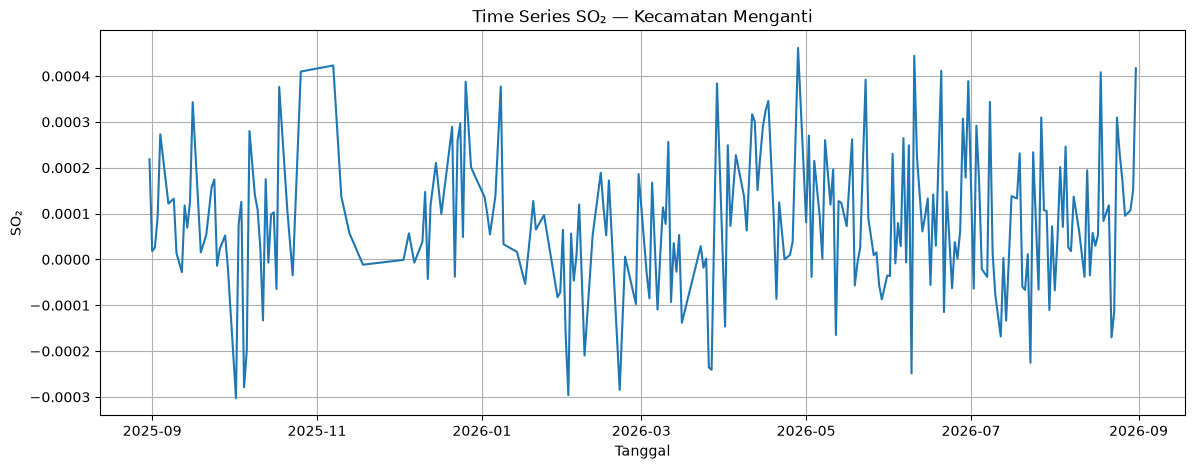

In [231]:
# 4.4 Plot time series SO2

plt.figure(figsize=(14, 5))
plt.plot(ts_so2["date"], ts_so2["SO2"])
plt.title("Time Series SO₂ — Kecamatan Menganti")
plt.xlabel("Tanggal")
plt.ylabel("SO₂")
plt.grid(True)
plt.show()


# 5. Konsep statistik dasar

Statistik deskriptif yang digunakan untuk membaca karakteristik data antara lain:

- **Mean**: rata-rata aritmetika
- **Median**: nilai tengah setelah data diurutkan
- **Minimum / maksimum**: nilai ekstrem bawah dan atas
- **Range**: selisih maksimum dan minimum
- **Variance**: ukuran penyebaran kuadrat terhadap mean
- **Standard deviation**: akar dari variance
- **Quartile / IQR**: ukuran sebaran bagian tengah data
- **Skewness**: kemiringan distribusi
- **Kurtosis**: keruncingan distribusi

Perhitungan manual di bawah menggunakan contoh kecil agar langkah matematis mudah diperiksa.


In [232]:
# 5.1 Contoh hitungan manual statistik

x = np.array([2, 4, 5, 4, 9])

n = len(x)
mean_manual = np.sum(x) / n

x_sorted = np.sort(x)
median_manual = x_sorted[n // 2]

variance_population_manual = np.sum((x - mean_manual) ** 2) / n
std_population_manual = np.sqrt(variance_population_manual)

range_manual = np.max(x) - np.min(x)

print("Data :", x.tolist())
print("Mean :", mean_manual)
print("Median :", median_manual)
print("Range :", range_manual)
print("Variance populasi :", variance_population_manual)
print("Std populasi :", std_population_manual)


Data : [2, 4, 5, 4, 9]
Mean : 4.8
Median : 4
Range : 7
Variance populasi : 5.36
Std populasi : 2.3151673805580453


## Contoh Perhitungan Manual — Mean

Untuk data:

$$ x = [2,4,5,4,9] $$

Rumus mean:

$$ \bar{x} = \frac{\sum_{i=1}^{n} x_i}{n} $$

Substitusi data:

$$ \bar{x} = \frac{2+4+5+4+9}{5} = \frac{24}{5} = 4.8 $$

Jadi, **mean = 4.8**.

# 6. Fitur TSFEL

TSFEL menghasilkan fitur yang dikelompokkan ke domain statistik, temporal, dan spectral. Dokumen contoh TSFEL yang digunakan dalam proyek ini membahas 68 fitur dan memberikan rumus serta contoh manual untuk masing-masing fitur.

Untuk tugas individual, fitur yang dibagikan adalah:

## Hurst Exponent

Hurst Exponent digunakan untuk menggambarkan karakter dependensi/persistensi suatu deret waktu. Penjelasan rumus dan metode manual harus disesuaikan dengan metode yang digunakan oleh TSFEL pada versi environment proyek.

**Verifikasi:** nilai manual dan nilai TSFEL dibandingkan pada data yang sama.

> Bagian ini akan diisi setelah kita cek implementasi `hurst_exponent` yang tepat pada versi TSFEL di environment proyek, sehingga rumus manual tidak berbeda dengan fungsi yang benar-benar dipanggil.


In [233]:
# 6.1 Verifikasi Hurst Exponent dengan TSFEL

import inspect
import tsfel.feature_extraction.features as tsfel_features

print(inspect.signature(tsfel_features.hurst_exponent))
print(inspect.getsource(tsfel_features.hurst_exponent))


(signal)
@set_domain("domain", "fractal")
def hurst_exponent(signal):
    """Computes the Hurst exponent of the signal through the Rescaled range
    (R/S) analysis.

    Parameters
    ----------
    signal : np.ndarray
        Input signal.

    Returns
    -------
    h_exp : float
        Hurst exponent.
    """
    global warning_flag

    if np.var(signal) == 0 and np.all(signal == signal[0]):
        return np.nan

    n = len(signal)

    if n < FEATURES_MIN_SIZE:
        if not warning_flag:
            warnings.warn(warning_msg, UserWarning)
            warning_flag = True
        return np.nan

    lags = set(np.linspace(4, n // 10, n // 2, dtype=int))
    rs = [compute_rs(signal, lag) for lag in lags]

    n_values = np.array(list(lags))[np.isfinite(rs)]
    rs = np.array(rs)[np.isfinite(rs)]

    coeffs = np.polyfit(np.log10(n_values), np.log10(rs), 1)
    h_exp = coeffs[0]

    return h_exp



# 7. Membaca data hasil ekstraksi seluruh kelas

Setiap file mempunyai identitas:

- `id`
- `nama`
- `daerah`

serta 68 fitur TSFEL.

Dataset utama 204 fitur akan dibuat dengan menggabungkan ketiga polutan berdasarkan identitas mahasiswa.


In [234]:
# 7.1 Load tiga file kelas

df_no2 = pd.read_csv(NO2_CLASS)
df_co = pd.read_csv(CO_CLASS)
df_so2 = pd.read_csv(SO2_CLASS)

print("NO2:", df_no2.shape)
print("CO :", df_co.shape)
print("SO2:", df_so2.shape)

print("\nKolom identitas:")
print(df_no2[["id", "nama", "daerah"]].head())


NO2: (37, 71)
CO : (37, 71)
SO2: (37, 71)

Kolom identitas:
   id                      nama                daerah
0   7   Okan Syailendra wahyudi                Manyar
1  10  Triswanti Jannatul Ma'wa  Kedungpring Lamongan
2  12           Laila Maghfiroh      Kamal, Bangkalan
3  13              Dedy Nurohim      sambeng lamongan
4  14     Ahmad Syahrul Farihin   Gresik Kota, Gresik


In [235]:
# 7.2 Validasi identitas mahasiswa

keys = ["id", "nama", "daerah"]

def normalize_name(series):
    return (
        series
        .astype(str)
        .str.strip()
        # Menyamakan spasi setelah tanda titik
        .str.replace(r"\.\s*", ". ", regex=True)
        # Menyamakan spasi berlebih
        .str.replace(r"\s+", " ", regex=True)
        # Menyamakan huruf besar/kecil
        .str.casefold()
    )

df_no2["nama_key"] = normalize_name(df_no2["nama"])
df_co["nama_key"] = normalize_name(df_co["nama"])
df_so2["nama_key"] = normalize_name(df_so2["nama"])

nama_no2 = set(df_no2["nama_key"])
nama_co = set(df_co["nama_key"])
nama_so2 = set(df_so2["nama_key"])

print("Jumlah nama NO2 :", len(nama_no2))
print("Jumlah nama CO  :", len(nama_co))
print("Jumlah nama SO2 :", len(nama_so2))

print("Nama sama NO2-CO :", len(nama_no2 & nama_co))
print("Nama sama NO2-SO2:", len(nama_no2 & nama_so2))
print("Nama sama CO-SO2 :", len(nama_co & nama_so2))
print("Nama sama ketiganya:", len(nama_no2 & nama_co & nama_so2))

Jumlah nama NO2 : 37
Jumlah nama CO  : 37
Jumlah nama SO2 : 37
Nama sama NO2-CO : 37
Nama sama NO2-SO2: 37
Nama sama CO-SO2 : 37
Nama sama ketiganya: 37


In [236]:
# 7.3 Menggabungkan menjadi 204 fitur

def prepare_pollutant(df, prefix):
    df = df.copy()

    # 68 fitur tidak termasuk kolom identitas
    feature_cols = [
        c for c in df.columns
        if c not in keys + ["nama_key"]
    ]

    # Pastikan jumlah fitur benar
    assert len(feature_cols) == 68, (
        f"{prefix} memiliki {len(feature_cols)} fitur, bukan 68"
    )

    result = df[["nama_key"] + feature_cols].copy()

    # Tambahkan prefix berdasarkan polutan
    result = result.rename(
        columns={
            c: f"{prefix}_{c}"
            for c in feature_cols
        }
    )

    return result


# Siapkan masing-masing polutan
no2_features = prepare_pollutant(df_no2, "NO2")
co_features = prepare_pollutant(df_co, "CO")
so2_features = prepare_pollutant(df_so2, "SO2")


# Gabungkan berdasarkan nama mahasiswa
merged_features = (
    no2_features
    .merge(co_features, on="nama_key", how="inner", validate="one_to_one")
    .merge(so2_features, on="nama_key", how="inner", validate="one_to_one")
)


# Simpan identitas mahasiswa dari dataset NO2
identity = df_no2[["id", "nama", "daerah", "nama_key"]].copy()

# Gabungkan identitas dengan 204 fitur
df_204 = identity.merge(
    merged_features,
    on="nama_key",
    how="inner",
    validate="one_to_one"
)


# Ambil hanya 204 kolom fitur
feature_cols_204 = [
    c for c in df_204.columns
    if c not in keys + ["nama_key"]
]


print("Shape dataset 204 fitur:", df_204.shape)
print("Jumlah fitur:", len(feature_cols_204))
print("Jumlah mahasiswa:", len(df_204))
print(
    "Missing:",
    df_204[feature_cols_204].isna().sum().sum()
)

display(
    df_204[
        ["id", "nama", "daerah"] + feature_cols_204[:5]
    ].head()
)

Shape dataset 204 fitur: (37, 208)
Jumlah fitur: 204
Jumlah mahasiswa: 37
Missing: 0


,id,nama,daerah,NO2_abs_energy,NO2_auc,NO2_autocorr,NO2_average_power,NO2_calc_centroid
0,7,Okan Syailendra wahyudi,Manyar,1.93304e-06,0.0239898,7,5.31055e-09,186.075
1,10,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,3.70206e-07,0.0109051,8,1.01426e-09,194.285
2,12,Laila Maghfiroh,"Kamal, Bangkalan",7.36359e-07,0.015059,11,2.01742e-09,166.04
3,13,Dedy Nurohim,sambeng lamongan,3.85402e-07,0.0112284,6,1.0559e-09,196.839
4,14,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",1.52398e-06,0.0224174,3,4.17529e-09,184.04


# 8. Standardisasi Fitur

K-Means menggunakan jarak terhadap centroid. Karena 204 fitur memiliki skala yang berbeda, fitur distandardisasi menggunakan Z-score melalui StandardScaler.

Rumus standardisasi:

$$ z = \frac{x-\mu}{\sigma} $$

dengan:

- $x$ = nilai asli suatu fitur
- $\mu$ = rata-rata fitur
- $\sigma$ = standar deviasi fitur
- $z$ = nilai fitur setelah standardisasi

Setelah standardisasi, setiap fitur berada pada skala yang sebanding sehingga tidak ada fitur dengan skala lebih besar yang mendominasi perhitungan jarak pada K-Means.

In [237]:
scaler_204 = StandardScaler()
X_204 = df_204[feature_cols_204].astype(float)

X_204_scaled = scaler_204.fit_transform(X_204)

print("Shape:", X_204_scaled.shape)
print("Mean mendekati 0:", np.mean(X_204_scaled, axis=0).mean())
print("Std rata-rata mendekati 1:", np.std(X_204_scaled, axis=0).mean())


Shape: (37, 204)
Mean mendekati 0: -6.385424495361987e-16
Std rata-rata mendekati 1: 0.9656862745098039


# 9. PCA 1–37

Kualitas clustering dibandingkan pada jumlah komponen PCA dari 1 sampai 37.

Untuk setiap jumlah komponen:
1. transformasi PCA
2. cari kandidat K dengan Elbow
3. evaluasi K-Means
4. simpan metrik clustering


In [238]:
# 9.1 PCA 1 sampai 37 — tabel explained variance

max_components = min(37, X_204_scaled.shape[0], X_204_scaled.shape[1])

pca_full = PCA(n_components=max_components)
X_pca_full = pca_full.fit_transform(X_204_scaled)

explained = pd.DataFrame({
    "PC": np.arange(1, max_components + 1),
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_full.explained_variance_ratio_)
})

display(explained)


,PC,explained_variance_ratio,cumulative_explained_variance
0,1,0.49939,0.49939
1,2,0.162095,0.661485
2,3,0.0987362,0.760222
3,4,0.0387984,0.79902
4,5,0.0361934,0.835213
5,6,0.0246921,0.859905
6,7,0.01836,0.878265
7,8,0.0162693,0.894535
8,9,0.0133907,0.907925
9,10,0.0113529,0.919278


In [239]:
# 9.2 Fungsi evaluasi K-Means untuk suatu jumlah PCA

def evaluate_kmeans(X, k_min=2, k_max=10, random_state=42):
    rows = []

    upper_k = min(k_max, len(X) - 1)

    for k in range(k_min, upper_k + 1):
        model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=10
        )

        labels = model.fit_predict(X)

        rows.append({
            "K": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels)
        })

    return pd.DataFrame(rows)


In [240]:
# 9.3 Evaluasi K-Means untuk PCA 1 sampai 37

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

pca_kmeans_results = []

for n_pc in range(1, 38):

    # Ambil PCA sebanyak n_pc
    X_pc = X_pca_full[:, :n_pc]

    for k in range(2, 11):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(X_pc)

        silhouette = silhouette_score(X_pc, labels)
        davies_bouldin = davies_bouldin_score(X_pc, labels)
        calinski_harabasz = calinski_harabasz_score(X_pc, labels)

        pca_kmeans_results.append({
            "n_pca": n_pc,
            "K": k,
            "inertia": kmeans.inertia_,
            "silhouette": silhouette,
            "davies_bouldin": davies_bouldin,
            "calinski_harabasz": calinski_harabasz
        })

# Ubah menjadi DataFrame
pca_kmeans_results = pd.DataFrame(pca_kmeans_results)

display(pca_kmeans_results.head())

,n_pca,K,inertia,silhouette,davies_bouldin,calinski_harabasz
0,1,2,14.2702,0.962142,0.00726805,8892.81
1,1,3,6.51715,0.564662,0.385158,9478.09
2,1,4,3.67796,0.462341,0.479034,10875.6
3,1,5,2.11951,0.525928,0.341405,13731.3
4,1,6,0.968146,0.518547,0.348476,23304.7


## Cara membaca metrik

- **Inertia**: semakin kecil, jarak dalam cluster semakin kecil; digunakan terutama untuk Elbow Method.
- **Silhouette Score**: semakin mendekati 1 berarti pemisahan cluster semakin jelas; nilai negatif menunjukkan banyak titik lebih dekat ke cluster lain.
- **Davies-Bouldin Index**: semakin kecil menunjukkan cluster yang lebih kompak dan lebih terpisah.
- **Calinski-Harabasz Index**: semakin besar menunjukkan rasio pemisahan antar-cluster terhadap penyebaran dalam-cluster yang lebih tinggi.

Tidak boleh menentukan “K terbaik” hanya dari satu angka tanpa melihat konteks metrik dan struktur cluster.


In [241]:
# 9.4 Pilih kandidat K berdasarkan silhouette tertinggi untuk setiap PCA

best_by_pca = (
    pca_kmeans_results
    .sort_values(["n_pca", "silhouette"], ascending=[True, False])
    .groupby("n_pca", as_index=False)
    .first()
)

display(best_by_pca)


,n_pca,K,inertia,silhouette,davies_bouldin,calinski_harabasz
0,1,2,14.2702,0.962142,0.00726805,8892.81
1,2,2,1194.01,0.905277,0.0449284,106.335
2,3,2,1913.62,0.86119,0.0756382,66.3492
3,4,2,2196.38,0.846645,0.0855236,57.808
4,5,2,2459.75,0.831192,0.0961745,51.6248
5,6,2,2639.72,0.822333,0.102295,48.1052
6,7,2,2773.55,0.814816,0.107709,45.7842
7,8,2,2892.12,0.807599,0.113817,43.9072
8,9,2,2989.73,0.803018,0.117219,42.4738
9,10,2,3072.47,0.798593,0.120756,41.3301


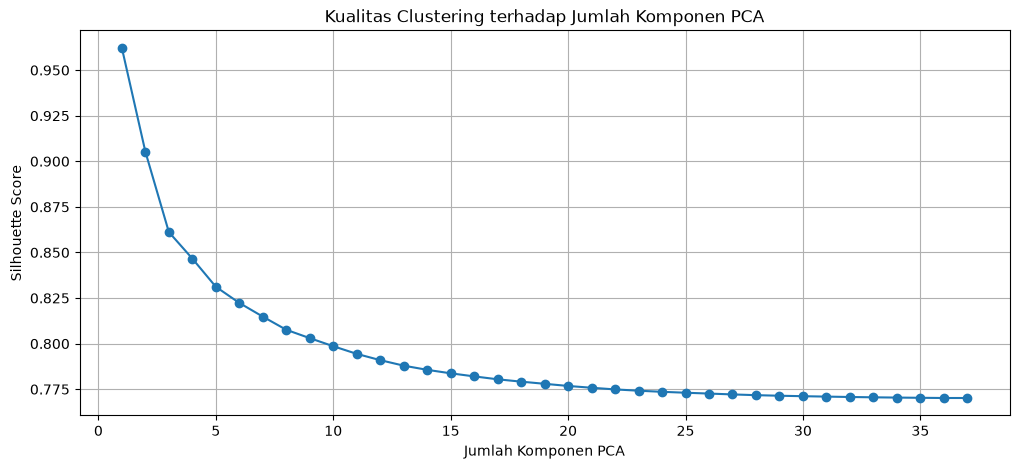

In [242]:
# 9.5 Visualisasi perubahan silhouette terhadap jumlah PCA

plt.figure(figsize=(12, 5))
plt.plot(
    best_by_pca["n_pca"],
    best_by_pca["silhouette"],
    marker="o"
)
plt.xlabel("Jumlah Komponen PCA")
plt.ylabel("Silhouette Score")
plt.title("Kualitas Clustering terhadap Jumlah Komponen PCA")
plt.grid(True)
plt.show()


# 10. Menentukan K menggunakan Elbow Method

Untuk K yang dipilih pada PCA tertentu, plot inertia untuk K=2 sampai K=10.

Pola “siku” menjadi kandidat K, kemudian diperiksa lagi menggunakan metrik evaluasi clustering.


,K,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,14.2702,0.962142,0.00726805,8892.81
1,3,6.51715,0.564662,0.385158,9478.09
2,4,3.67796,0.462341,0.479034,10875.6
3,5,2.11951,0.525928,0.341405,13731.3
4,6,0.968146,0.518547,0.348476,23304.7
5,7,0.535569,0.516479,0.355973,33978.1
6,8,0.350444,0.552077,0.305834,43027.7
7,9,0.256004,0.550835,0.33663,49762
8,10,0.17797,0.53061,0.282831,61356.5


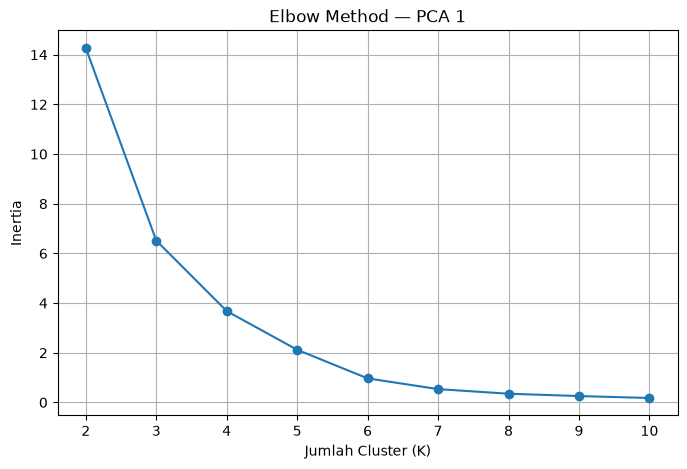

In [243]:
# Contoh: gunakan jumlah PCA yang dipilih setelah melihat hasil bagian 9.
# Jangan mengisi manual sebelum tabel best_by_pca diperiksa.

candidate_pca = int(best_by_pca.loc[best_by_pca["silhouette"].idxmax(), "n_pca"])
X_candidate = X_pca_full[:, :candidate_pca]

elbow_candidate = evaluate_kmeans(X_candidate)

display(elbow_candidate)

plt.figure(figsize=(8, 5))
plt.plot(elbow_candidate["K"], elbow_candidate["inertia"], marker="o")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title(f"Elbow Method — PCA {candidate_pca}")
plt.grid(True)
plt.show()


# 11. K-Means final pada dataset 204 fitur

Setelah jumlah komponen PCA dan K ditentukan dari hasil evaluasi, model final dijalankan dan label cluster ditambahkan ke identitas mahasiswa.

Nilai `candidate_pca` dan `final_k` harus berasal dari hasil analisis pada bagian sebelumnya.


In [244]:
# Isi final_k setelah pemeriksaan Elbow + metrik.
# Contoh berikut mengambil K dengan silhouette tertinggi pada PCA kandidat.

final_k = int(
    elbow_candidate.loc[elbow_candidate["silhouette"].idxmax(), "K"]
)

final_model = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

labels_204 = final_model.fit_predict(X_candidate)

hasil_cluster_204 = df_204[keys].copy()
hasil_cluster_204["cluster"] = labels_204

print("PCA digunakan:", candidate_pca)
print("K digunakan  :", final_k)

display(hasil_cluster_204)


PCA digunakan: 1
K digunakan  : 2


,id,nama,daerah,cluster
0,7,Okan Syailendra wahyudi,Manyar,0
1,10,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,0
2,12,Laila Maghfiroh,"Kamal, Bangkalan",0
3,13,Dedy Nurohim,sambeng lamongan,0
4,14,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",0
5,16,Rian Renaldy,"Waru, Pamekasan",0
6,18,Moh Rafie Nazar J,"Bangkalan Kota,Bangkalan",0
7,21,Ainur Raftuzzaki,Nunukan,0
8,25,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",0
9,27,Robbaniyah Umdatun Ni'mah,"Cerme, Gresik",0


In [245]:
# 11.1 Evaluasi final

final_silhouette = silhouette_score(X_candidate, labels_204)
final_db = davies_bouldin_score(X_candidate, labels_204)
final_ch = calinski_harabasz_score(X_candidate, labels_204)

print("Silhouette Score      :", final_silhouette)
print("Davies-Bouldin Index  :", final_db)
print("Calinski-Harabasz     :", final_ch)


Silhouette Score      : 0.9621421712491911
Davies-Bouldin Index  : 0.007268053216452457
Calinski-Harabasz     : 8892.811968264623


# 12. Analisis 68 fitur

Tahap ini diulang menggunakan 68 fitur dalam satu polutan, mengikuti pola pekerjaan contoh teman. Analisis dapat dilakukan terpisah untuk NO₂, CO, dan SO₂.

Untuk setiap polutan:
1. pilih 68 fitur
2. StandardScaler
3. PCA
4. Elbow Method
5. K-Means
6. Silhouette / DBI / CH
7. visualisasi dan profiling cluster


In [246]:
def run_68_feature_analysis(
    df,
    pollutant,
    identity_cols=("id", "nama", "daerah", "nama_key")
):
    identity_cols = list(identity_cols)

    feature_cols = [
        c for c in df.columns
        if c not in identity_cols
    ]

    # Pastikan tepat 68 fitur
    assert len(feature_cols) == 68, (
        f"{pollutant} memiliki {len(feature_cols)} fitur, bukan 68"
    )

    X = df[feature_cols].astype(float)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=min(37, X_scaled.shape[0], X_scaled.shape[1]))
    X_pca = pca.fit_transform(X_scaled)

    inertia = []
    K_range = range(2, 11)

    for k in K_range:
        kmeans_temp = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        kmeans_temp.fit(X_pca)
        inertia.append(kmeans_temp.inertia_)

    return {
        "feature_cols": feature_cols,
        "X_scaled": X_scaled,
        "X_pca": X_pca,
        "pca_model": pca,
        "inertia": inertia,
        "K_range": list(K_range)
    }

In [247]:
# 12.1 Jalankan analisis untuk masing-masing polutan

analysis_no2 = run_68_feature_analysis(df_no2, "NO2")
analysis_co = run_68_feature_analysis(df_co, "CO")
analysis_so2 = run_68_feature_analysis(df_so2, "SO2")

print("Analisis 68 fitur selesai.")

Analisis 68 fitur selesai.


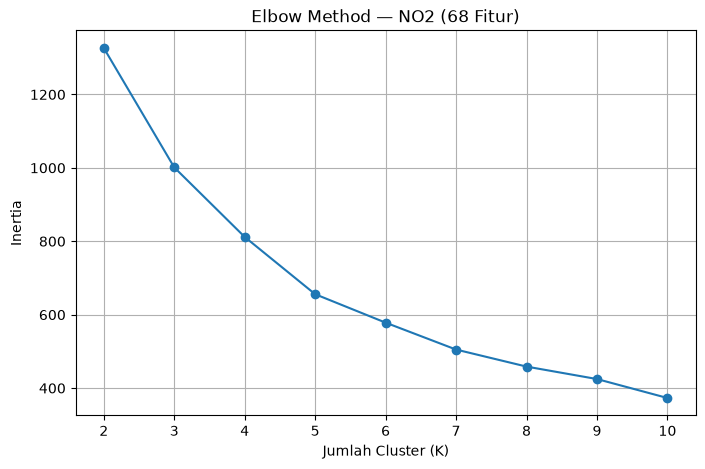

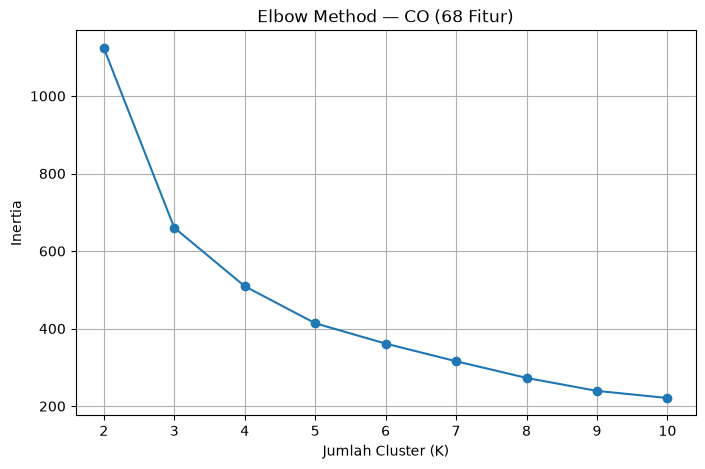

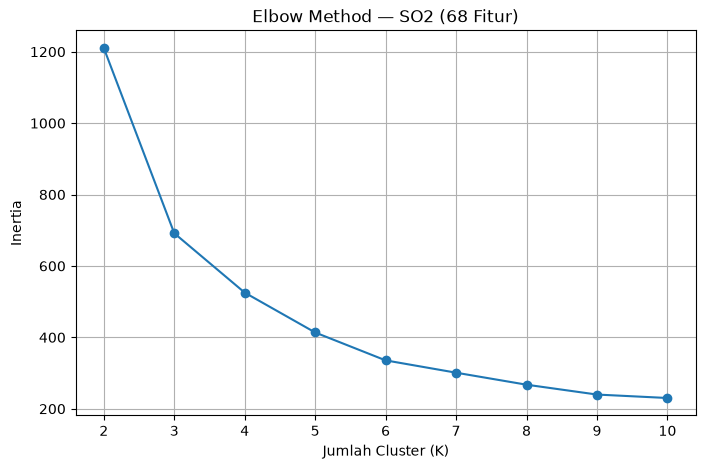

In [248]:
# 12.2 Plot Elbow untuk masing-masing polutan

for pollutant, result in [
    ("NO2", analysis_no2),
    ("CO", analysis_co),
    ("SO2", analysis_so2)
]:
    plt.figure(figsize=(8, 5))

    plt.plot(
        result["K_range"],
        result["inertia"],
        marker="o"
    )

    plt.xlabel("Jumlah Cluster (K)")
    plt.ylabel("Inertia")
    plt.title(f"Elbow Method — {pollutant} (68 Fitur)")
    plt.grid(True)
    plt.show()

In [249]:
# 12.3 Evaluasi K-Means untuk masing-masing polutan — 68 fitur

def evaluate_68_features(result):
    X_pca = result["X_pca"]
    K_range = range(2, 11)

    rows = []

    for k in K_range:
        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(X_pca)

        rows.append({
            "K": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_pca, labels),
            "davies_bouldin": davies_bouldin_score(X_pca, labels),
            "calinski_harabasz": calinski_harabasz_score(X_pca, labels)
        })

    return pd.DataFrame(rows)


eval_no2_68 = evaluate_68_features(analysis_no2)
eval_co_68 = evaluate_68_features(analysis_co)
eval_so2_68 = evaluate_68_features(analysis_so2)

print("=== NO2 — 68 Fitur ===")
display(eval_no2_68)

print("=== CO — 68 Fitur ===")
display(eval_co_68)

print("=== SO2 — 68 Fitur ===")
display(eval_so2_68)

=== NO2 — 68 Fitur ===


,K,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,1326.58,0.745489,0.163103,29.4289
1,3,1001.28,0.190722,1.12567,24.4609
2,4,811.799,0.20453,0.999696,22.0895
3,5,655.79,0.216606,0.846203,21.79
4,6,578.312,0.185596,0.94948,19.9803
5,7,504.99,0.161947,1.02869,19.1787
6,8,458.599,0.166889,0.986332,17.9175
7,9,424.659,0.151594,1.20074,16.6267
8,10,373.028,0.172124,0.867316,16.6393


=== CO — 68 Fitur ===


,K,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,1123.8,0.795494,0.124689,39.9021
1,3,660.214,0.697034,0.159113,44.9269
2,4,509.374,0.342517,0.694459,40.9363
3,5,413.89,0.184501,0.927503,38.4858
4,6,361.352,0.153812,0.984529,35.0645
5,7,315.868,0.161337,0.880005,33.0697
6,8,272.854,0.14249,0.841078,32.3733
7,9,239.323,0.150055,0.858393,31.6722
8,10,221.039,0.145469,0.807706,29.6413


=== SO2 — 68 Fitur ===


,K,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,1210.46,0.789366,0.127864,35.6095
1,3,691.645,0.708469,0.151285,43.0221
2,4,525.289,0.392088,0.533434,40.1376
3,5,413.679,0.406057,0.473969,39.2251
4,6,335.556,0.135855,0.879872,38.9204
5,7,301.064,0.126801,0.959841,35.5562
6,8,267.416,0.099564,1.00295,33.6891
7,9,239.818,0.120845,0.80175,32.1396
8,10,230.172,0.0924375,1.12546,28.8284


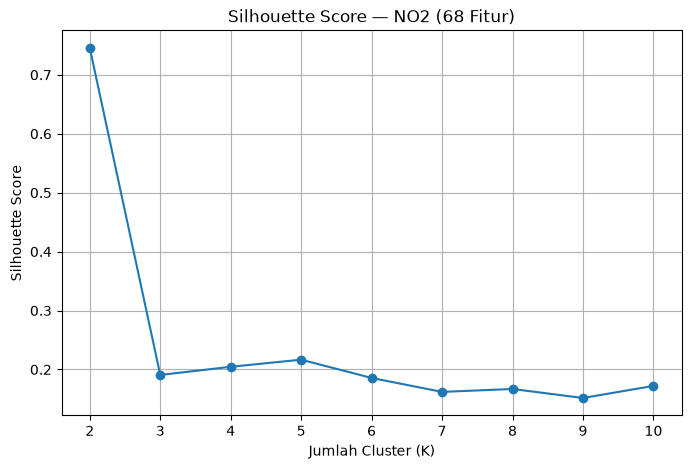

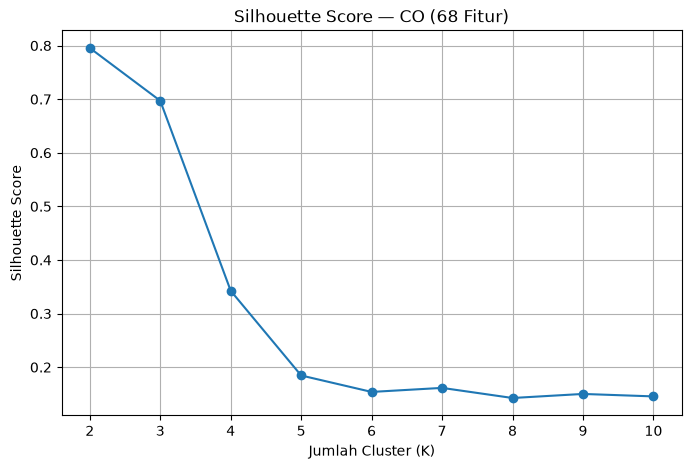

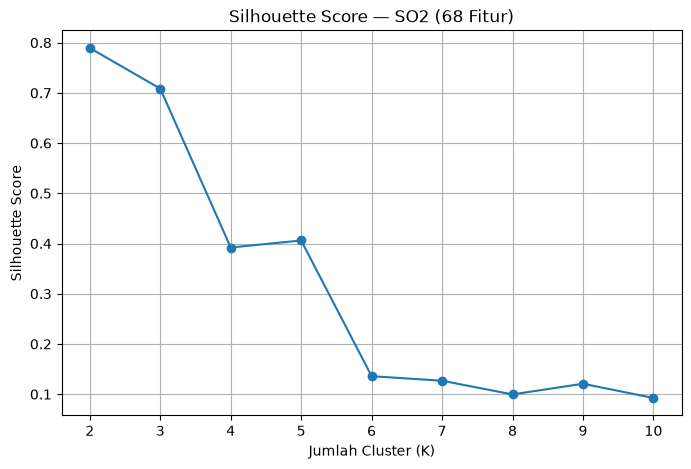

In [250]:
# 12.4 Perbandingan Silhouette Score — 68 Fitur

for pollutant, result in [
    ("NO2", eval_no2_68),
    ("CO", eval_co_68),
    ("SO2", eval_so2_68)
]:
    plt.figure(figsize=(8, 5))

    plt.plot(
        result["K"],
        result["silhouette"],
        marker="o"
    )

    plt.xlabel("Jumlah Cluster (K)")
    plt.ylabel("Silhouette Score")
    plt.title(f"Silhouette Score — {pollutant} (68 Fitur)")
    plt.grid(True)
    plt.show()

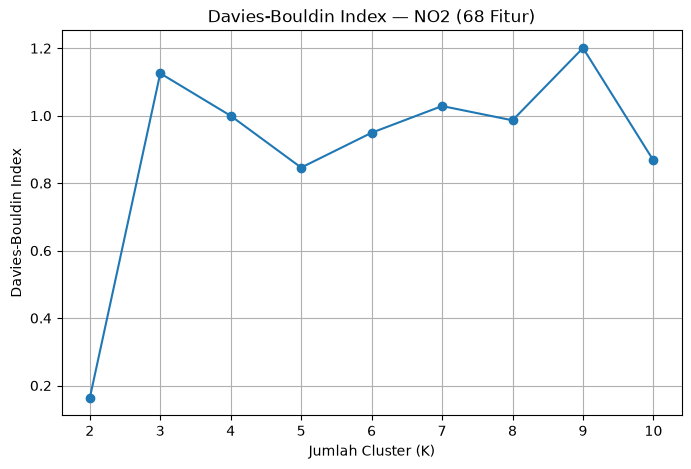

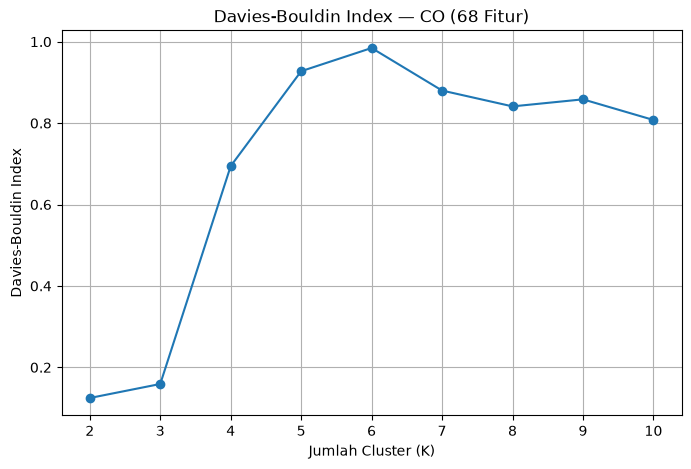

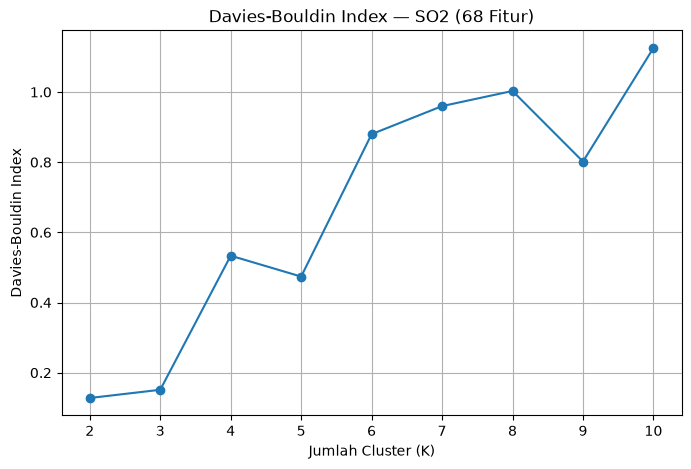

In [251]:
# 12.5 Davies-Bouldin Index — 68 Fitur

for pollutant, result in [
    ("NO2", eval_no2_68),
    ("CO", eval_co_68),
    ("SO2", eval_so2_68)
]:
    plt.figure(figsize=(8, 5))

    plt.plot(
        result["K"],
        result["davies_bouldin"],
        marker="o"
    )

    plt.xlabel("Jumlah Cluster (K)")
    plt.ylabel("Davies-Bouldin Index")
    plt.title(f"Davies-Bouldin Index — {pollutant} (68 Fitur)")
    plt.grid(True)
    plt.show()

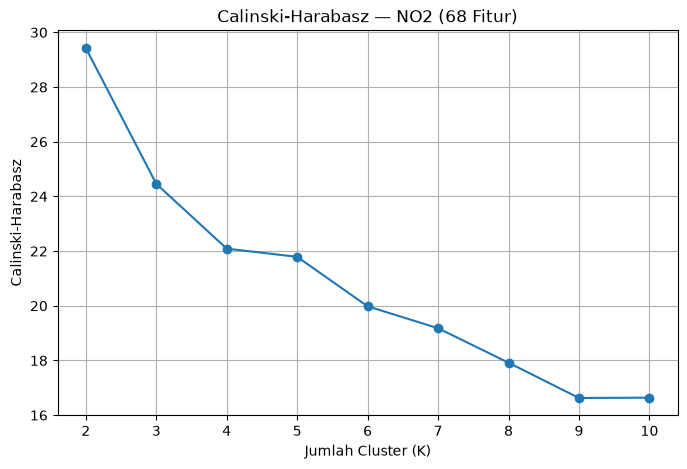

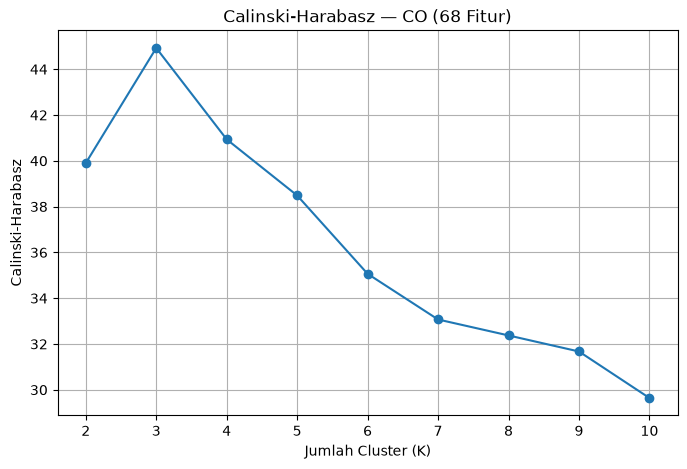

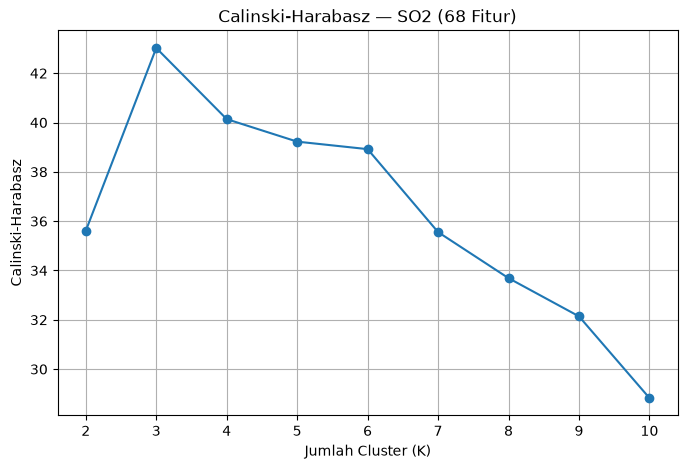

In [252]:
# 12.6 Calinski-Harabasz — 68 Fitur

for pollutant, result in [
    ("NO2", eval_no2_68),
    ("CO", eval_co_68),
    ("SO2", eval_so2_68)
]:
    plt.figure(figsize=(8, 5))

    plt.plot(
        result["K"],
        result["calinski_harabasz"],
        marker="o"
    )

    plt.xlabel("Jumlah Cluster (K)")
    plt.ylabel("Calinski-Harabasz")
    plt.title(f"Calinski-Harabasz — {pollutant} (68 Fitur)")
    plt.grid(True)
    plt.show()

In [253]:
# 12.7 Kandidat K terbaik berdasarkan Silhouette

best_68 = pd.DataFrame([
    {
        "pollutant": "NO2",
        "K_silhouette": eval_no2_68.loc[
            eval_no2_68["silhouette"].idxmax(), "K"
        ],
        "silhouette": eval_no2_68["silhouette"].max(),
        "K_davies_bouldin": eval_no2_68.loc[
            eval_no2_68["davies_bouldin"].idxmin(), "K"
        ],
        "davies_bouldin": eval_no2_68["davies_bouldin"].min(),
        "K_calinski_harabasz": eval_no2_68.loc[
            eval_no2_68["calinski_harabasz"].idxmax(), "K"
        ],
        "calinski_harabasz": eval_no2_68["calinski_harabasz"].max()
    },
    {
        "pollutant": "CO",
        "K_silhouette": eval_co_68.loc[
            eval_co_68["silhouette"].idxmax(), "K"
        ],
        "silhouette": eval_co_68["silhouette"].max(),
        "K_davies_bouldin": eval_co_68.loc[
            eval_co_68["davies_bouldin"].idxmin(), "K"
        ],
        "davies_bouldin": eval_co_68["davies_bouldin"].min(),
        "K_calinski_harabasz": eval_co_68.loc[
            eval_co_68["calinski_harabasz"].idxmax(), "K"
        ],
        "calinski_harabasz": eval_co_68["calinski_harabasz"].max()
    },
    {
        "pollutant": "SO2",
        "K_silhouette": eval_so2_68.loc[
            eval_so2_68["silhouette"].idxmax(), "K"
        ],
        "silhouette": eval_so2_68["silhouette"].max(),
        "K_davies_bouldin": eval_so2_68.loc[
            eval_so2_68["davies_bouldin"].idxmin(), "K"
        ],
        "davies_bouldin": eval_so2_68["davies_bouldin"].min(),
        "K_calinski_harabasz": eval_so2_68.loc[
            eval_so2_68["calinski_harabasz"].idxmax(), "K"
        ],
        "calinski_harabasz": eval_so2_68["calinski_harabasz"].max()
    }
])

display(best_68)

,pollutant,K_silhouette,silhouette,K_davies_bouldin,davies_bouldin,K_calinski_harabasz,calinski_harabasz
0,NO2,2,0.745489,2,0.163103,2,29.4289
1,CO,2,0.795494,2,0.124689,3,44.9269
2,SO2,2,0.789366,2,0.127864,3,43.0221


In [254]:
# 12.8 Clustering final 68 fitur

final_k_no2 = int(
    eval_no2_68.loc[eval_no2_68["silhouette"].idxmax(), "K"]
)

final_k_co = int(
    eval_co_68.loc[eval_co_68["silhouette"].idxmax(), "K"]
)

final_k_so2 = int(
    eval_so2_68.loc[eval_so2_68["silhouette"].idxmax(), "K"]
)

kmeans_no2 = KMeans(
    n_clusters=final_k_no2,
    random_state=42,
    n_init=10
)

kmeans_co = KMeans(
    n_clusters=final_k_co,
    random_state=42,
    n_init=10
)

kmeans_so2 = KMeans(
    n_clusters=final_k_so2,
    random_state=42,
    n_init=10
)

labels_no2 = kmeans_no2.fit_predict(analysis_no2["X_pca"])
labels_co = kmeans_co.fit_predict(analysis_co["X_pca"])
labels_so2 = kmeans_so2.fit_predict(analysis_so2["X_pca"])

hasil_no2_68 = df_no2[["id", "nama", "daerah"]].copy()
hasil_no2_68["cluster"] = labels_no2

hasil_co_68 = df_co[["id", "nama", "daerah"]].copy()
hasil_co_68["cluster"] = labels_co

hasil_so2_68 = df_so2[["id", "nama", "daerah"]].copy()
hasil_so2_68["cluster"] = labels_so2

print("K NO2:", final_k_no2)
print("K CO :", final_k_co)
print("K SO2:", final_k_so2)

K NO2: 2
K CO : 2
K SO2: 2


In [255]:
# 12.9 Distribusi anggota cluster

print("=== Distribusi Cluster NO2 ===")
print(hasil_no2_68["cluster"].value_counts().sort_index())

print("\n=== Distribusi Cluster CO ===")
print(hasil_co_68["cluster"].value_counts().sort_index())

print("\n=== Distribusi Cluster SO2 ===")
print(hasil_so2_68["cluster"].value_counts().sort_index())

=== Distribusi Cluster NO2 ===
cluster
0    36
1     1
Name: count, dtype: int64

=== Distribusi Cluster CO ===
cluster
0    36
1     1
Name: count, dtype: int64

=== Distribusi Cluster SO2 ===
cluster
0    36
1     1
Name: count, dtype: int64


In [256]:
print("=== HASIL CLUSTER NO2 ===")
display(
    hasil_no2_68.sort_values("cluster")
)

print("=== HASIL CLUSTER CO ===")
display(
    hasil_co_68.sort_values("cluster")
)

print("=== HASIL CLUSTER SO2 ===")
display(
    hasil_so2_68.sort_values("cluster")
)

=== HASIL CLUSTER NO2 ===


,id,nama,daerah,cluster
0,7,Okan Syailendra wahyudi,Manyar,0
1,10,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,0
2,12,Laila Maghfiroh,"Kamal, Bangkalan",0
3,13,Dedy Nurohim,sambeng lamongan,0
4,14,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",0
5,16,Rian Renaldy,"Waru, Pamekasan",0
6,18,Moh Rafie Nazar J,"Bangkalan Kota,Bangkalan",0
7,21,Ainur Raftuzzaki,Nunukan,0
8,25,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",0
9,27,Robbaniyah Umdatun Ni'mah,"Cerme, Gresik",0


=== HASIL CLUSTER CO ===


,id,nama,daerah,cluster
0,3,Nurhabibatul Umah,"Kerek, Tuban",0
1,4,Verdi Setyawan Ardiansyah Putra,Menganti Gresik,0
2,5,Okan Syailendra wahyudi,"Manyar, Gresik",0
3,6,Mochammad Zaenal Abidin,"Widang, Tuban",0
4,7,M. Hendrik Purwanto,"Sreseh, Sampang",0
5,8,Robbaniyah Umdatun Ni'mah,"Cerme, Gresik",0
6,10,Ainur Raftuzzaki,Nunukan,0
7,11,Magdalena Jovita Hatuopar,"Pilangkenceng, Madiun",0
8,12,Rachelia Andini Tendean,"Tikala, Manado",0
9,13,Kurnia Maulinda Sari,"Labang, Bangkalan",0


=== HASIL CLUSTER SO2 ===


,id,nama,daerah,cluster
0,2,Nurhabibatul Umah,"Kerek, Tuban",0
1,3,Verdi Setyawan Ardiansyah Putra,Menganti Gresik,0
2,4,Okan Syailendra wahyudi,"Manyar, Gresik",0
3,5,Mochammad Zaenal Abidin,"Widang, Tuban",0
4,6,M. Hendrik Purwanto,"Sreseh, Sampang",0
5,7,Robbaniyah Umdatun Ni'mah,"Cerme, Gresik",0
6,9,Ainur Raftuzzaki,Nunukan,0
7,10,Magdalena Jovita Hatuopar,"Pilangkenceng, Madiun",0
8,11,Rachelia Andini Tendean,"Tikala, Manado",0
9,12,Marshella Aulia Putri,"Kec. Kalianget, Sumenep",0


In [257]:
# 12.10 Profil cluster berdasarkan daerah

for pollutant, hasil in [
    ("NO2", hasil_no2_68),
    ("CO", hasil_co_68),
    ("SO2", hasil_so2_68)
]:
    print(f"\n===== PROFIL CLUSTER {pollutant} =====")

    profil = (
        hasil
        .groupby(["cluster", "daerah"])
        .size()
        .reset_index(name="jumlah")
        .sort_values(
            ["cluster", "jumlah"],
            ascending=[True, False]
        )
    )

    display(profil)


===== PROFIL CLUSTER NO2 =====


,cluster,daerah,jumlah
8,0,"Kamal, Bangkalan",2
15,0,"Kwanyar, Bangkalan",2
0,0,"Asemrowo, Surabaya",1
1,0,"Bandung, Jogoroto, Jombang",1
2,0,"Bangkalan Kota,Bangkalan",1
3,0,"Banyu Ajuh, Perumnas, Kamal",1
4,0,Baron Nganjuk,1
5,0,"Cerme, Gresik",1
6,0,"Dukun, Gresik",1
7,0,"Gresik Kota, Gresik",1



===== PROFIL CLUSTER CO =====


,cluster,daerah,jumlah
7,0,"Kamal, Bangkalan",2
15,0,"Kwanyar, Bangkalan",2
0,0,"Asemrowo, Surabaya",1
1,0,"Bandung, Jogoroto, Jombang",1
2,0,"Banyu Ajuh, Perumnas, Kamal",1
3,0,Baron Nganjuk,1
4,0,"Cerme, Gresik",1
5,0,"Dukun, Gresik",1
6,0,"Gresik Kota, Gresik",1
8,0,"Kec. Bangkalan, Kab. Bangkalan",1



===== PROFIL CLUSTER SO2 =====


,cluster,daerah,jumlah
7,0,"Kamal, Bangkalan",2
15,0,"Kwanyar, Bangkalan",2
0,0,"Asemrowo, Surabaya",1
1,0,"Bandung, Jogoroto, Jombang",1
2,0,"Banyu Ajuh, Perumnas, Kamal",1
3,0,Baron Nganjuk,1
4,0,"Cerme, Gresik",1
5,0,"Dukun, Gresik",1
6,0,"Gresik Kota, Gresik",1
8,0,"Kec. Bangkalan, Kab. Bangkalan",1


# 13. Kesimpulan

Berdasarkan seluruh tahapan analisis, data deret waktu **CO, NO₂, dan SO₂** telah melalui proses persiapan data, pemeriksaan missing value, preprocessing, serta ekstraksi fitur menggunakan TSFEL. Setiap data polutan menghasilkan **68 fitur**, sehingga tiga polutan menghasilkan total **204 fitur per mahasiswa**.

Dataset gabungan terdiri dari **37 mahasiswa** dengan **204 fitur** dan tidak memiliki missing value. Selanjutnya seluruh fitur distandardisasi menggunakan `StandardScaler` agar fitur memiliki skala yang sebanding sebelum dilakukan analisis PCA dan K-Means.

## 13.1 Hasil PCA

PCA dilakukan menggunakan jumlah komponen **1 sampai 37**. Pada dataset 204 fitur, komponen pertama menjelaskan sekitar **49,939%** variasi data. Dua komponen pertama menjelaskan sekitar **66,149%**, sedangkan tiga komponen pertama menjelaskan sekitar **76,022%** variasi data.

Berdasarkan evaluasi K-Means pada berbagai jumlah komponen PCA, nilai silhouette tertinggi diperoleh pada penggunaan **1 komponen PCA dengan K=2**. Pada konfigurasi tersebut diperoleh:

- Silhouette Score = **0,962142**
- Davies-Bouldin Index = **0,007268**
- Calinski-Harabasz Index = **8892,812**

## 13.2 Hasil Clustering 204 Fitur

Dengan konfigurasi PCA 1 dan K=2, dataset terbagi menjadi dua cluster. Cluster pertama berisi **36 mahasiswa**, sedangkan cluster kedua hanya berisi **1 mahasiswa**, yaitu observasi Dewi Geizya dari daerah Kamal, Banyuajuh.

Pemisahan satu observasi tersebut juga menyebabkan nilai evaluasi internal clustering menjadi sangat tinggi. Oleh karena itu, hasil ini perlu dipahami sebagai kondisi clustering pada dataset yang digunakan, bukan langsung sebagai bukti bahwa terdapat dua kelompok karakteristik polutan yang berbeda secara umum.

## 13.3 Analisis 68 Fitur Per Polutan

Analisis tambahan dilakukan secara terpisah untuk masing-masing polutan menggunakan 68 fitur.

Untuk **NO₂**, K=2 menghasilkan Silhouette Score sebesar **0,745489** dan Davies-Bouldin Index sebesar **0,163103**. Calinski-Harabasz juga mencapai nilai maksimum pada K=2.

Untuk **CO**, K=2 menghasilkan Silhouette Score sebesar **0,795494** dan Davies-Bouldin Index sebesar **0,124689**. Calinski-Harabasz memiliki nilai maksimum pada K=3, sehingga terdapat perbedaan hasil antar-metrik.

Untuk **SO₂**, K=2 menghasilkan Silhouette Score sebesar **0,789366** dan Davies-Bouldin Index sebesar **0,127864**. Sama seperti CO, nilai Calinski-Harabasz maksimum diperoleh pada K=3.

Dalam implementasi akhir, K dipilih berdasarkan **Silhouette Score**, sehingga jumlah cluster yang digunakan adalah **2 cluster untuk NO₂, CO, dan SO₂**.

## 13.4 Interpretasi Cluster Berdasarkan Daerah

Pada ketiga analisis 68 fitur, cluster utama berisi 36 mahasiswa dari berbagai daerah, sedangkan cluster kedua hanya terdiri dari observasi **Kamal, Banyuajuh**.

Dengan demikian, clustering menunjukkan bahwa observasi Kamal, Banyuajuh memiliki karakteristik fitur yang berbeda dari observasi lainnya pada dataset yang digunakan. Namun, karena cluster tersebut hanya terdiri dari satu observasi, interpretasi terhadap pola wilayah tidak dapat digeneralisasikan sebagai karakteristik seluruh wilayah Kamal.

## 13.5 Keterbatasan Analisis

Salah satu keterbatasan utama adalah adanya satu observasi dengan nilai fitur yang jauh berbeda dari observasi lainnya. Data mentah dan tahapan preprocessing sumber observasi tersebut tidak tersedia sehingga penyebab perbedaan skala tidak dapat diverifikasi lebih lanjut.

Selain itu, jumlah data relatif kecil, yaitu **37 mahasiswa**, dibandingkan dengan jumlah fitur yang cukup besar, yaitu **204 fitur**. Oleh karena itu, hasil PCA dan K-Means sangat sensitif terhadap karakteristik beberapa observasi.

Hasil clustering pada notebook ini sebaiknya dipahami sebagai **hasil eksplorasi dan pengelompokan berdasarkan dataset yang tersedia**, bukan sebagai kesimpulan kausal mengenai sumber atau tingkat pencemaran suatu wilayah.

## 13.6 Kesimpulan Akhir

Secara keseluruhan, seluruh tahapan analisis telah berhasil dilakukan mulai dari preprocessing data, ekstraksi 68 fitur TSFEL untuk tiga polutan, pembentukan dataset 204 fitur, standardisasi, PCA, penentuan jumlah cluster, hingga evaluasi K-Means menggunakan Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index.

Dataset 204 fitur menghasilkan **2 cluster**, sedangkan analisis terpisah 68 fitur juga menghasilkan **2 cluster** untuk NO₂, CO, dan SO₂ berdasarkan Silhouette Score. Hasil clustering menunjukkan adanya satu observasi yang terpisah dari mayoritas data, sehingga interpretasi hasil perlu mempertimbangkan karakteristik dan keterbatasan dataset.